# Community ECS assessment

Clean driver for [`community_ecs.stan`](community_ecs.stan). The notebook keeps assessed numerical inputs separate from model switches, runs named scenarios, and stores both live results and durable run files.

Use the **`stan` mamba environment** for this notebook. Run the cells from top to bottom.

In [42]:
import json
import re
import sys
from copy import deepcopy
from datetime import datetime
from pathlib import Path

import cmdstanpy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde, norm, skewnorm

# Work whether Jupyter starts in bayecs/ or in its parent directory.
ROOT = Path.cwd().resolve()
if not (ROOT / "community_ecs.stan").exists():
    candidate = ROOT / "bayecs"
    if (candidate / "community_ecs.stan").exists():
        ROOT = candidate

STAN_FILE = ROOT / "community_ecs.stan"
assert STAN_FILE.exists(), f"Stan file not found: {STAN_FILE}"

# The stan environment bundles CmdStan at <environment>/bin/cmdstan.
# Use CmdStanPy's configured location when available, with that local
# environment path as a fallback.
ENV_BIN = Path(sys.executable).resolve().parent
try:
    CMDSTAN_PATH = Path(cmdstanpy.cmdstan_path())
except ValueError:
    env_cmdstan = ENV_BIN / "cmdstan"
    if not env_cmdstan.exists():
        raise RuntimeError(
            "CmdStan was not found. Run this notebook with the stan mamba environment."
        )
    cmdstanpy.set_cmdstan_path(str(env_cmdstan))
    CMDSTAN_PATH = env_cmdstan

# Prefer the stan environment's matching GNU compiler over any compiler
# inherited from the host's shell modules. This avoids TBB ABI conflicts.
ENV_CXX = ENV_BIN / "x86_64-conda-linux-gnu-g++"
CPP_OPTIONS = {"CXX": str(ENV_CXX)} if ENV_CXX.exists() else {}

print("Stan file:", STAN_FILE)
print("CmdStanPy:", cmdstanpy.__version__)
print("CmdStan:", CMDSTAN_PATH)
print("C++ compiler:", CPP_OPTIONS.get("CXX", "CmdStan default"))

Stan file: /glade/derecho/scratch/vcooper/projects/bayecs/community_ecs.stan
CmdStanPy: 1.2.1
CmdStan: /glade/derecho/scratch/vcooper/conda/envs/stan/bin/cmdstan
C++ compiler: /glade/derecho/scratch/vcooper/conda/envs/stan/bin/x86_64-conda-linux-gnu-g++


## Assessed inputs

These are the current central values and 1-sigma uncertainties from `Cooper_baselines.ipynb`. Every input remains present even when its line of evidence is disabled, because the unified Stan model has one fixed data interface.

In [26]:
ERF_2X = 3.93
SIG_ERF_2X = 0.29
CO2_PI = 284.7

# Historical pattern-effect skew-normal parameters.
HIST_DLAMBDA_SHAPE = -3.7573
HIST_DLAMBDA_LOC = 0.9726
HIST_DLAMBDA_SCALE = 0.5195

# Latent-Gaussian correlations used only when the copula is enabled.
# The historical values induce approximately -0.10 Pearson correlation
# with the present skew-normal historical marginal.
RHO_HIST_LGM = -0.10176464
RHO_HIST_PLIO = -0.10176464
RHO_LGM_PLIO = 0.50

# Optional Process-lambda / ERF2x correlation. Negative means that a
# larger (more-positive) F_2xCO2 accompanies a more-negative lambda.
RHO_LAMBDA_F2X = -0.50

BASE_INPUTS = {
    # Shared forcing and state dependence
    "erf_2x": ERF_2X,
    "sig_F2xCO2": SIG_ERF_2X,
    "rho_lambda_F2x": RHO_LAMBDA_F2X,
    "mu_zeta": 0.0,
    "sig_zeta": 0.0001,

    # Process evidence
    "mu_lambda": -0.98,
    "sig_lambda": 0.38,

    # Historical evidence
    "mu_T_hist": 1.09,
    "sig_T_hist": np.sqrt(0.08**2 + 0.07**2),
    "mu_N_hist": 0.81,
    "sig_N_hist": 0.20,
    "mu_F_CO2_hist": 1.799415916648319,
    "mu_F_anthro_aerosol_hist": -0.9692081647180485,
    "sig_F_anthro_aerosol_hist": 0.3422096809303118,
    "mu_F_other_hist": 1.819726885758719,
    "sig_F_other_hist": 0.1749319089184633,
    "shape_dlambda": HIST_DLAMBDA_SHAPE,
    "loc_dlambda": HIST_DLAMBDA_LOC,
    "scale_dlambda": HIST_DLAMBDA_SCALE,

    # 2006--2024 Trend evidence (per decade)
    "mu_F_trend": 0.6792412527839783,
    "sig_F_trend": 0.17692313445510519,
    "mu_T_trend": 0.2973752655080024,
    "sig_T_trend": 0.07059634070974388,
    "mu_N_trend": 0.45236271230928726,
    "sig_N_trend": 0.16146898421227077,
    "cov_TN_trend": -0.002970,
    "mu_dlambda_trend": 0.0,
    "sig_dlambda_trend": 0.30,

    # LGM evidence
    "mu_T_LGM": -6.0,
    "sig_T_LGM": 1.0,
    "mu_F_other_LGM": -4.5,
    "sig_F_other_LGM": 2.1,
    "mu_f_CO2_LGM": -0.55,
    "sig_f_CO2_LGM": 0.04,
    "mu_N_LGM": 0.0,
    "sig_N_LGM": 0.1 / 1.645,
    "mu_dlambda_LGM": -0.42,
    "sig_dlambda_LGM": 0.34,

    # Mid-Pliocene evidence
    "mu_T_plio": 4.1,
    "sig_T_plio": 0.6,
    "mu_CO2_plio": 367.0,
    "sig_CO2_plio": 30.0,
    "CO2_PI": CO2_PI,
    "mu_F_plio_nonGHG": 1.76,
    "sig_F_plio_nonGHG": 1.0,
    "mu_N_plio": 0.0,
    "sig_N_plio": 0.1 / 1.645,
    "mu_dlambda_plio": -0.44,
    "sig_dlambda_plio": 0.40,
    "mu_fCH4": 0.43,
    "sig_fCH4": 0.08,

    # Pattern-effect correlations
    "rho_dlambda_hist_LGM": RHO_HIST_LGM,
    "rho_dlambda_hist_plio": RHO_HIST_PLIO,
    "rho_dlambda_LGM_plio": RHO_LGM_PLIO,
}

print(f"{len(BASE_INPUTS)} assessed inputs defined")

54 assessed inputs defined


## Model switches

Each setting is binary. `use_uniform_lambda_prior=1` selects a uniform feedback prior; `0` selects a uniform ECS prior. That choice remains available whether Process evidence is on or off. `use_lambda_F2x_correlation=1` uses the assessed `rho_lambda_F2x` in a bivariate Gaussian Process/forcing term and therefore requires Process evidence.

The baseline requested here uses a uniform-lambda prior, includes Process, Historical, LGM, and Pliocene, excludes Trend, and uses neither optional correlation structure.

In [27]:
SWITCH_NAMES = (
    "use_uniform_lambda_prior",
    "include_process",
    "use_lambda_F2x_correlation",
    "include_historical",
    "include_trend",
    "include_lgm",
    "include_pliocene",
    "use_pattern_effect_copula",
)

BASELINE_SWITCHES = {
    "use_uniform_lambda_prior": 1,
    "include_process": 1,
    "use_lambda_F2x_correlation": 0,
    "include_historical": 1,
    "include_trend": 0,
    "include_lgm": 1,
    "include_pliocene": 1,
    "use_pattern_effect_copula": 0,
}

def _validate_data(data):
    expected = set(BASE_INPUTS) | set(SWITCH_NAMES)
    missing = expected - set(data)
    extra = set(data) - expected
    if missing or extra:
        raise ValueError(f"Data keys differ from expected; missing={missing}, extra={extra}")

    bad_switches = {k: data[k] for k in SWITCH_NAMES if data[k] not in (0, 1)}
    if bad_switches:
        raise ValueError(f"Switches must be 0 or 1: {bad_switches}")

    if data["use_lambda_F2x_correlation"]:
        if not data["include_process"]:
            raise ValueError(
                "lambda/F_2xCO2 correlation requires include_process=1"
            )
        if not -1 < data["rho_lambda_F2x"] < 1:
            raise ValueError("rho_lambda_F2x must lie strictly between -1 and 1")

    if data["include_trend"]:
        trend_cov = np.array([
            [data["sig_T_trend"]**2, data["cov_TN_trend"]],
            [data["cov_TN_trend"], data["sig_N_trend"]**2],
        ])
        np.linalg.cholesky(trend_cov)

    if data["use_pattern_effect_copula"]:
        copula_r = np.array([
            [1.0, data["rho_dlambda_hist_LGM"], data["rho_dlambda_hist_plio"]],
            [data["rho_dlambda_hist_LGM"], 1.0, data["rho_dlambda_LGM_plio"]],
            [data["rho_dlambda_hist_plio"], data["rho_dlambda_LGM_plio"], 1.0],
        ])
        np.linalg.cholesky(copula_r)
    elif not -1 < data["rho_dlambda_LGM_plio"] < 1:
        raise ValueError("rho_dlambda_LGM_plio must lie strictly between -1 and 1")


def make_data(switch_updates=None, input_updates=None):
    """Build and validate one complete community_ecs.stan data dictionary."""
    switches = dict(BASELINE_SWITCHES)
    switch_updates = {} if switch_updates is None else dict(switch_updates)
    input_updates = {} if input_updates is None else dict(input_updates)

    unknown_switches = set(switch_updates) - set(SWITCH_NAMES)
    unknown_inputs = set(input_updates) - set(BASE_INPUTS)
    if unknown_switches:
        raise KeyError(f"Unknown model switches: {sorted(unknown_switches)}")
    if unknown_inputs:
        raise KeyError(f"Unknown assessed inputs: {sorted(unknown_inputs)}")

    switches.update(switch_updates)
    inputs = dict(BASE_INPUTS)
    inputs.update(input_updates)
    data = dict(inputs, **switches)
    _validate_data(data)
    return data


baseline_data = make_data()
pd.Series(BASELINE_SWITCHES, name="baseline").to_frame()

,baseline
use_uniform_lambda_prior,1
include_process,1
use_lambda_F2x_correlation,0
include_historical,1
include_trend,0
include_lgm,1
include_pliocene,1
use_pattern_effect_copula,0


## Initialization and sampling controls

The model samples `l` (lambda) directly and reports `S` as a transformed parameter. Initial values therefore contain `l`, not `S`. The default sampling size is suitable for comparisons; increase `iter_sampling` for final tail estimates if needed.

In [28]:
def make_init(data, ecs_initial=3.0, init_updates=None):
    init = {
        "F_2xCO2": data["erf_2x"],
        "l": -data["erf_2x"] / ecs_initial,
        "zeta": data["mu_zeta"],
        "F_anthro_aerosol_hist": data["mu_F_anthro_aerosol_hist"],
        "F_other_hist": data["mu_F_other_hist"],
        "T_hist": data["mu_T_hist"],
        "dlambda": skewnorm.ppf(
            0.5, a=data["shape_dlambda"],
            loc=data["loc_dlambda"], scale=data["scale_dlambda"],
        ),
        "T_LGM": data["mu_T_LGM"],
        "F_other_LGM": data["mu_F_other_LGM"],
        "f_CO2_LGM": data["mu_f_CO2_LGM"],
        "dlambda_LGM": data["mu_dlambda_LGM"],
        "T_plio": data["mu_T_plio"],
        "CO2_plio": data["mu_CO2_plio"],
        "F_plio_nonGHG": data["mu_F_plio_nonGHG"],
        "dlambda_plio": data["mu_dlambda_plio"],
        "fCH4": data["mu_fCH4"],
        "F_trend": data["mu_F_trend"],
        "T_trend": data["mu_T_trend"],
        "dlambda_trend": data["mu_dlambda_trend"],
    }
    if init_updates:
        unknown = set(init_updates) - set(init)
        if unknown:
            raise KeyError(f"Unknown initial-value parameters: {sorted(unknown)}")
        init.update(init_updates)
    return init


SAMPLING_DEFAULTS = {
    "chains": 4,
    "parallel_chains": 4,
    # Quick comparison defaults; increase these for final tail estimates.
    "iter_warmup": 1_000,
    "iter_sampling": 5_000,
    "adapt_delta": 0.95,
    "max_treedepth": 12,
    "seed": 20250812,
    "show_progress": True,
    "show_console": False,
    "refresh": 500,
}

make_init(baseline_data)

{'F_2xCO2': 3.93,
 'l': -1.31,
 'zeta': 0.0,
 'F_anthro_aerosol_hist': -0.9692081647180485,
 'F_other_hist': 1.819726885758719,
 'T_hist': 1.09,
 'dlambda': 0.6224390559414669,
 'T_LGM': -6.0,
 'F_other_LGM': -4.5,
 'f_CO2_LGM': -0.55,
 'dlambda_LGM': -0.42,
 'T_plio': 4.1,
 'CO2_plio': 367.0,
 'F_plio_nonGHG': 1.76,
 'dlambda_plio': -0.44,
 'fCH4': 0.43,
 'F_trend': 0.6792412527839783,
 'T_trend': 0.2973752655080024,
 'dlambda_trend': 0.0}

## Compile once

In [29]:
community_model = cmdstanpy.CmdStanModel(
    stan_file=str(STAN_FILE), cpp_options=CPP_OPTIONS
)
print("Compiled model:", community_model.exe_file)

Compiled model: /glade/derecho/scratch/vcooper/projects/bayecs/community_ecs


## Reusable scenario runner

Each completed run is placed in `results[name]`. CmdStan CSV files, the exact input data, run metadata, and a summary CSV are also written beneath `community_ecs_results/`. A rerun with the same name replaces the in-memory entry but does not overwrite the earlier timestamped directory.

In [30]:
RESULTS_ROOT = ROOT / "community_ecs_results"
results = {}


def run_scenario(
    name, *, switch_updates=None, input_updates=None,
    sampling_updates=None, init_updates=None, ecs_initial=3.0,
):
    """Run one named scenario and save its fit, inputs, and summaries."""
    if not re.fullmatch(r"[A-Za-z0-9_.-]+", name):
        raise ValueError("name may contain only letters, numbers, '.', '_' and '-'")

    data = make_data(switch_updates=switch_updates, input_updates=input_updates)
    inits = make_init(data, ecs_initial=ecs_initial, init_updates=init_updates)
    sampling = dict(SAMPLING_DEFAULTS)
    if sampling_updates:
        sampling.update(sampling_updates)

    stamp = datetime.now().strftime("%Y%m%dT%H%M%S_%f")
    run_dir = RESULTS_ROOT / f"{name}_{stamp}"
    run_dir.mkdir(parents=True, exist_ok=False)
    cmdstanpy.write_stan_json(str(run_dir / "data.json"), data)

    metadata = {
        "name": name,
        "created": stamp,
        "stan_file": str(STAN_FILE),
        "switches": {key: data[key] for key in SWITCH_NAMES},
        "sampling": sampling,
    }
    with (run_dir / "metadata.json").open("w") as handle:
        json.dump(metadata, handle, indent=2)

    print(f"Running {name!r}")
    print("Switches:", metadata["switches"])
    fit = community_model.sample(
        data=data, inits=inits, output_dir=str(run_dir), **sampling
    )
    summary = fit.summary()
    summary.to_csv(run_dir / "summary.csv")

    entry = {
        "fit": fit,
        "data": data,
        "inits": inits,
        "switches": metadata["switches"],
        "sampling": sampling,
        "summary": summary,
        "S": fit.stan_variable("S"),
        "l": fit.stan_variable("l"),
        "output_dir": run_dir,
    }
    results[name] = entry

    divergences = int(np.sum(fit.method_variables()["divergent__"]))
    s_quantiles = np.quantile(entry["S"], [0.05, 0.17, 0.50, 0.83, 0.95])
    print("S quantiles [5, 17, 50, 83, 95]%:", np.round(s_quantiles, 3))
    print("Divergences:", divergences)
    print("Saved to:", run_dir)
    return entry


def compare_scenarios(names=None):
    """Return an ECS comparison table for completed scenarios."""
    names = list(results) if names is None else list(names)
    rows = []
    for name in names:
        entry = results[name]
        s = entry["S"]
        q = np.quantile(s, [0.05, 0.17, 0.50, 0.83, 0.95])
        fit = entry["fit"]
        rows.append({
            "scenario": name,
            "mean": np.mean(s),
            "sd": np.std(s, ddof=1),
            "p05": q[0], "p17": q[1], "p50": q[2],
            "p83": q[3], "p95": q[4],
            "divergences": int(np.sum(fit.method_variables()["divergent__"])),
            "R_hat_S": entry["summary"].loc["S", "R_hat"],
            "ESS_bulk_S": entry["summary"].loc["S", "ESS_bulk"],
        })
    return pd.DataFrame(rows).set_index("scenario").round(3)

## Baseline calculation

This runs the requested baseline: uniform lambda, Process + Historical + LGM + Pliocene, no Trend, no three-way pattern-effect copula, and no optional lambda/ERF2x correlation.

In [31]:
baseline = run_scenario("baseline")
compare_scenarios()

15:59:25 - cmdstanpy - INFO - CmdStan start processing


Running 'baseline'
Switches: {'use_uniform_lambda_prior': 1, 'include_process': 1, 'use_lambda_F2x_correlation': 0, 'include_historical': 1, 'include_trend': 0, 'include_lgm': 1, 'include_pliocene': 1, 'use_pattern_effect_copula': 0}


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

15:59:51 - cmdstanpy - INFO - CmdStan done processing.
15:59:51 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Random variable is -nan, but must be not nan! (in 'community_ecs.stan', line 442, column 8 to column 44)
	Exception: normal_lpdf: Random variable is -nan, but must be not nan! (in 'community_ecs.stan', line 442, column 8 to column 44)
Exception: normal_lpdf: Random variable is -nan, but must be not nan! (in 'community_ecs.stan', line 442, column 8 to column 44)
	Exception: normal_lpdf: Random variable is -nan, but must be not nan! (in 'community_ecs.stan', line 442, column 8 to column 44)
	Exception: normal_lpdf: Random variable is -nan, but must be not nan! (in 'community_ecs.stan', line 442, column 8 to column 44)
	Exception: normal_lpdf: Random variable is -nan, but must be not nan! (in 'community_ecs.stan', line 442, column 8 to column 44)
Exception: normal_lpdf: Random variable is -nan, but must be not nan! (in 'community_ecs.stan', line 


S quantiles [5, 17, 50, 83, 95]%: [2.445 2.755 3.344 4.198 5.192]
Divergences: 0
Saved to: /glade/derecho/scratch/vcooper/projects/bayecs/community_ecs_results/baseline_20260812T155925_446673


,mean,sd,p05,p17,p50,p83,p95,divergences,R_hat_S,ESS_bulk_S
scenario,,,,,,,,,,
baseline,3.533,1.013,2.445,2.755,3.344,4.198,5.192,0,1.0,10200.8


In [32]:
SUMMARY_VARIABLES = [
    "S", "l", "F_2xCO2", "zeta",
    "dlambda", "dlambda_LGM", "dlambda_plio",
    "F_CO2_hist", "F_anthro_aerosol_hist", "F_other_hist", "F_hist",
    "f_CO2_LGM", "F_CO2_LGM",
    "CO2_plio", "f_CO2_plio", "F_plio_CO2",
]
baseline["summary"].loc[SUMMARY_VARIABLES]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
S,3.532530,1.625720e-02,1.013280,0.721248,2.444920,3.344030,5.191680,10200.8,7243.32,158.101,1.00024
l,-1.172110,2.486530e-03,0.255384,0.250621,-1.593300,-1.172000,-0.753297,10984.0,7465.39,170.239,1.00019
F_2xCO2,3.919220,1.793340e-03,0.281603,0.279691,3.455100,3.916740,4.381210,24722.2,13986.90,383.166,1.00027
zeta,-0.000001,6.993870e-07,0.000099,0.000100,-0.000164,-0.000001,0.000161,20212.5,12482.90,313.270,1.00043
dlambda,0.578198,2.200780e-03,0.277320,0.279256,0.079079,0.605954,0.980629,17379.4,13435.00,269.360,1.00010
dlambda_LGM,-0.239257,2.560440e-03,0.282346,0.281263,-0.698575,-0.241279,0.226444,12286.9,11724.20,190.432,1.00013
dlambda_plio,-0.283343,2.761070e-03,0.302312,0.303691,-0.780924,-0.282808,0.216518,12182.5,12018.00,188.814,1.00043
F_CO2_hist,1.794480,8.211120e-04,0.128937,0.128061,1.581980,1.793350,2.006010,24722.2,13986.90,383.165,1.00027
F_anthro_aerosol_hist,-0.939930,2.160300e-03,0.296143,0.295591,-1.425490,-0.939680,-0.457391,18889.3,14865.30,292.762,1.00020
F_other_hist,1.827970,1.065390e-03,0.170243,0.171730,1.548440,1.828440,2.110010,25619.0,14452.30,397.065,1.00002


## Alternative settings

Uncomment any example below. Only settings that differ from the baseline need to be supplied. You can also change assessed values for a sensitivity test through `input_updates`.

In [33]:
with_trend = run_scenario(
    "with_trend", switch_updates={"include_trend": 1}
)

with_copula = run_scenario(
    "with_copula", switch_updates={"use_pattern_effect_copula": 1}
)

with_lambda_F2x_correlation = run_scenario(
    "with_lambda_F2x_correlation",
    switch_updates={"use_lambda_F2x_correlation": 1},
    # Uses the default rho_lambda_F2x=-0.5. Override it, if desired, with:
    # input_updates={"rho_lambda_F2x": -0.3},
)

# no_process_uniform_lambda = run_scenario(
#     "no_process_UL", switch_updates={"include_process": 0}
# )

# no_process_uniform_s = run_scenario(
#     "no_process_US",
#     switch_updates={"include_process": 0, "use_uniform_lambda_prior": 0},
# )

# historical_only = run_scenario(
#     "historical_only",
#     switch_updates={"include_process": 0, "include_lgm": 0, "include_pliocene": 0},
# )

# process_mean_sensitivity = run_scenario(
#     "process_mean_minus_1p10", input_updates={"mu_lambda": -1.10}
# )

Running 'with_trend'
Switches: {'use_uniform_lambda_prior': 1, 'include_process': 1, 'use_lambda_F2x_correlation': 0, 'include_historical': 1, 'include_trend': 1, 'include_lgm': 1, 'include_pliocene': 1, 'use_pattern_effect_copula': 0}


15:59:53 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

...

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

16:01:27 - cmdstanpy - INFO - CmdStan done processing.
16:01:27 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Random variable is -nan, but must be not nan! (in 'community_ecs.stan', line 442, column 8 to column 44)
	Exception: normal_lpdf: Random variable is -nan, but must be not nan! (in 'community_ecs.stan', line 442, column 8 to column 44)
Exception: normal_lpdf: Random variable is -nan, but must be not nan! (in 'community_ecs.stan', line 442, column 8 to column 44)
	Exception: normal_lpdf: Random variable is -nan, but must be not nan! (in 'community_ecs.stan', line 442, column 8 to column 44)
	Exception: normal_lpdf: Random variable is -nan, but must be not nan! (in 'community_ecs.stan', line 442, column 8 to column 44)
	Exception: normal_lpdf: Random variable is -nan, but must be not nan! (in 'community_ecs.stan', line 442, column 8 to column 44)
Exception: normal_lpdf: Random variable is -nan, but must be not nan! (in 'community_ecs.stan', line 


S quantiles [5, 17, 50, 83, 95]%: [2.561 2.85  3.387 4.2   5.088]
Divergences: 0
Saved to: /glade/derecho/scratch/vcooper/projects/bayecs/community_ecs_results/with_lambda_F2x_correlation_20260812T160100_514448


In [34]:
# Compare every completed scenario.
compare_scenarios()

,mean,sd,p05,p17,p50,p83,p95,divergences,R_hat_S,ESS_bulk_S
scenario,,,,,,,,,,
baseline,3.533,1.013,2.445,2.755,3.344,4.198,5.192,0,1.0,10200.8
with_trend,3.591,0.898,2.497,2.834,3.423,4.296,5.183,0,1.0,13579.8
with_copula,3.469,0.843,2.438,2.753,3.321,4.124,4.984,0,1.0,12169.5
with_lambda_F2x_correlation,3.547,0.821,2.561,2.850,3.387,4.200,5.088,0,1.0,13037.5


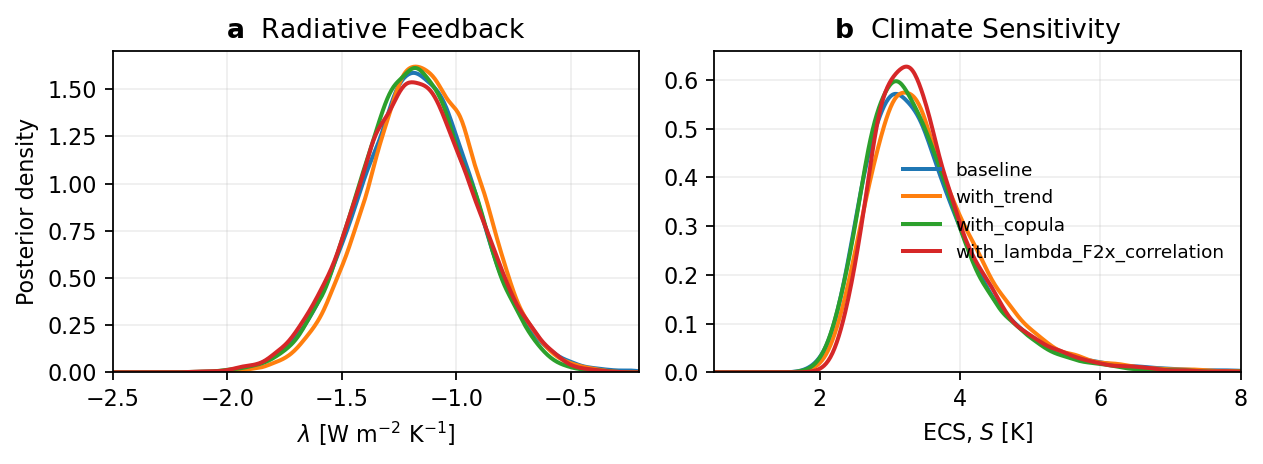

In [37]:
# Plot lambda and ECS posterior densities for every completed scenario.
POSTERIOR_LAMBDA_GRID = np.linspace(-2.5, -0.2, 500)
POSTERIOR_S_GRID = np.linspace(0.5, 8.0, 500)

if results:
    fig, axs = plt.subplots(1, 2, figsize=(8.0, 3.0), dpi=160)
    for name, entry in results.items():
        axs[0].plot(
            POSTERIOR_LAMBDA_GRID,
            gaussian_kde(entry["l"])(POSTERIOR_LAMBDA_GRID),
            lw=1.8, label=name,
        )
        axs[1].plot(
            POSTERIOR_S_GRID,
            gaussian_kde(entry["S"])(POSTERIOR_S_GRID),
            lw=1.8, label=name,
        )

    axs[0].set(
        xlabel=r"$\lambda$ [W m$^{-2}$ K$^{-1}$]",
        ylabel="Posterior density",
        xlim=POSTERIOR_LAMBDA_GRID[[0, -1]],
        title=r"$\mathbf{a}$  Radiative Feedback",
    )
    axs[1].set(
        xlabel=r"ECS, $S$ [K]",
        xlim=POSTERIOR_S_GRID[[0, -1]],
        title=r"$\mathbf{b}$  Climate Sensitivity",
    )
    for ax in axs:
        ax.set_ylim(bottom=0)
        ax.grid(alpha=0.2)
        # ax.set_title(ax.get_title(), loc="left")
    axs[1].legend(frameon=False, fontsize="small")
    plt.tight_layout()
    plt.show()

## Line-of-evidence likelihoods

These diagnostics use the same score-$N$ equations and nuisance distributions as the Stan model. Historical and Trend Gaussian nuisance variables are marginalized semi-analytically. The nonlinear paleo terms use reproducible common-random-number Monte Carlo.

Each curve is a **relative likelihood**, normalized to its own maximum. The $S$ curves are calculated directly as $L(\mathrm{data}\mid S)$ while marginalizing the assessed $F_{2\times CO_2}$ uncertainty; they are not transformed PDFs and therefore do not receive a Jacobian. The joint-paleo calculation averages the product of the LGM and Pliocene likelihoods using shared $F_{2\times CO_2}$ and $\zeta$ draws and correlated paleo pattern-effect draws.

In [43]:
LIKELIHOOD_DEFAULTS = {
    # Quick, smooth defaults. Increase mc_draws/grid_points for publication.
    "lambda_min": -4.0,
    "lambda_max": -0.05,
    "S_min": 0.5,
    "S_max": 10.0,
    "grid_points": 260,
    "mc_draws": 30_000,
    "seed": 20250813,
}

INDIVIDUAL_EVIDENCE = ("Process", "Historical", "Trend", "LGM", "Pliocene")
PALEO_EVIDENCE = ("LGM", "Pliocene", "Joint paleo")

LIKELIHOOD_STYLES = {
    "Process": dict(color="0.25", ls="-"),
    "Historical": dict(color="forestgreen", ls="-"),
    "Trend": dict(color="royalblue", ls="-"),
    "LGM": dict(color="tab:purple", ls="--"),
    "Pliocene": dict(color="darkorange", ls="--"),
    "Joint paleo": dict(color="firebrick", ls="-"),
}


def _relative_likelihood(values):
    values = np.asarray(values, dtype=float)
    peak = np.nanmax(values)
    if not np.isfinite(peak) or peak <= 0:
        raise ValueError("Likelihood curve has no finite positive values")
    return values / peak


def _normal_density_from_variance(observed, predicted_mean, variance):
    variance = np.maximum(np.asarray(variance, dtype=float), 1e-14)
    return np.exp(-0.5 * (observed - predicted_mean)**2 / variance) / np.sqrt(
        2 * np.pi * variance
    )


def _meinshausen_co2_sarf(co2_ppm, n2o_ppb=273.0):
    co2_ppm = np.asarray(co2_ppm, dtype=float)
    a1, b1, c1, d1 = -2.4785e-7, 7.5906e-4, -2.1492e-3, 5.2488
    co2_ref = 277.15
    co2_alpha_max = co2_ref - b1 / (2 * a1)
    alpha_prime = np.where(
        co2_ppm <= co2_ref,
        d1,
        np.where(
            co2_ppm < co2_alpha_max,
            d1 + a1 * (co2_ppm - co2_ref)**2 + b1 * (co2_ppm - co2_ref),
            d1 - b1**2 / (4 * a1),
        ),
    )
    return (alpha_prime + c1 * np.sqrt(n2o_ppb)) * np.log(co2_ppm / co2_ref)


def _plio_co2_f2x_ratio(co2_ppm, co2_pi):
    return (
        _meinshausen_co2_sarf(co2_ppm) - _meinshausen_co2_sarf(co2_pi)
    ) / (
        _meinshausen_co2_sarf(2 * co2_pi) - _meinshausen_co2_sarf(co2_pi)
    )

In [44]:
def calculate_likelihoods(
    label="baseline", *, input_updates=None, settings_updates=None,
    process_correlation=False,
):
    """Calculate marginal likelihoods on lambda and S grids.

    input_updates changes assessed parameters for one sensitivity version.
    settings_updates changes grids, sample count, or seed.
    process_correlation=True applies rho_lambda_F2x to the Process curve.
    """
    data = dict(BASE_INPUTS)
    input_updates = {} if input_updates is None else dict(input_updates)
    unknown_inputs = set(input_updates) - set(data)
    if unknown_inputs:
        raise KeyError(f"Unknown likelihood inputs: {sorted(unknown_inputs)}")
    data.update(input_updates)

    settings = dict(LIKELIHOOD_DEFAULTS)
    settings_updates = {} if settings_updates is None else dict(settings_updates)
    unknown_settings = set(settings_updates) - set(settings)
    if unknown_settings:
        raise KeyError(f"Unknown likelihood settings: {sorted(unknown_settings)}")
    settings.update(settings_updates)

    lambda_grid = np.linspace(
        settings["lambda_min"], settings["lambda_max"],
        int(settings["grid_points"]),
    )
    S_grid = np.linspace(
        settings["S_min"], settings["S_max"],
        int(settings["grid_points"]),
    )
    n = int(settings["mc_draws"])
    rng = np.random.default_rng(settings["seed"])

    # Common draws are reused across every grid point and line of evidence.
    F2x = rng.normal(data["erf_2x"], data["sig_F2xCO2"], n)
    zeta = rng.normal(data["mu_zeta"], data["sig_zeta"], n)
    dlambda_hist = skewnorm.rvs(
        a=data["shape_dlambda"], loc=data["loc_dlambda"],
        scale=data["scale_dlambda"], size=n, random_state=rng,
    )
    dlambda_trend = rng.normal(
        data["mu_dlambda_trend"], data["sig_dlambda_trend"], n
    )

    paleo_dlambda_cov = np.array([
        [
            data["sig_dlambda_LGM"]**2,
            data["rho_dlambda_LGM_plio"]
            * data["sig_dlambda_LGM"] * data["sig_dlambda_plio"],
        ],
        [
            data["rho_dlambda_LGM_plio"]
            * data["sig_dlambda_LGM"] * data["sig_dlambda_plio"],
            data["sig_dlambda_plio"]**2,
        ],
    ])
    paleo_dlambda = rng.multivariate_normal(
        [data["mu_dlambda_LGM"], data["mu_dlambda_plio"]],
        paleo_dlambda_cov, size=n,
    )
    dlambda_lgm, dlambda_plio = paleo_dlambda.T
    f_co2_lgm = rng.normal(data["mu_f_CO2_LGM"], data["sig_f_CO2_LGM"], n)
    co2_plio = rng.normal(data["mu_CO2_plio"], data["sig_CO2_plio"], n)
    f_ch4 = rng.normal(data["mu_fCH4"], data["sig_fCH4"], n)
    f_co2_plio = _plio_co2_f2x_ratio(co2_plio, data["CO2_PI"])

    rho_process = data["rho_lambda_F2x"] if process_correlation else 0.0
    if not -1 < rho_process < 1:
        raise ValueError("rho_lambda_F2x must lie strictly between -1 and 1")

    hist_forcing_mean = (
        data["mu_F_CO2_hist"] * F2x / data["erf_2x"]
        + data["mu_F_anthro_aerosol_hist"] + data["mu_F_other_hist"]
    )
    hist_forcing_variance = (
        data["sig_F_anthro_aerosol_hist"]**2
        + data["sig_F_other_hist"]**2
    )

    def evaluate_at_lambda(lam, scalar_lambda, S_value=None):
        # Process: the lambda marginal is unchanged by its F2x correlation.
        if scalar_lambda:
            process_like = norm.pdf(lam, data["mu_lambda"], data["sig_lambda"])
        else:
            # Exact marginal for lambda = -F2x/S, including optional covariance.
            process_residual_mean = data["mu_lambda"] + data["erf_2x"] / S_value
            process_residual_variance = (
                data["sig_lambda"]**2
                + (data["sig_F2xCO2"] / S_value)**2
                + 2 * rho_process * data["sig_lambda"]
                * data["sig_F2xCO2"] / S_value
            )
            process_like = _normal_density_from_variance(
                0.0, process_residual_mean, process_residual_variance
            )

        beta_hist = lam - dlambda_hist
        hist_mean = hist_forcing_mean + data["mu_T_hist"] * beta_hist
        hist_variance = (
            data["sig_N_hist"]**2 + hist_forcing_variance
            + beta_hist**2 * data["sig_T_hist"]**2
        )
        historical_like = np.mean(_normal_density_from_variance(
            data["mu_N_hist"], hist_mean, hist_variance
        ))

        beta_trend = lam - dlambda_trend
        trend_mean = data["mu_F_trend"] + data["mu_T_trend"] * beta_trend
        trend_variance = (
            data["sig_N_trend"]**2 + data["sig_F_trend"]**2
            + beta_trend**2 * data["sig_T_trend"]**2
            - 2 * beta_trend * data["cov_TN_trend"]
        )
        trend_like = np.mean(_normal_density_from_variance(
            data["mu_N_trend"], trend_mean, trend_variance
        ))

        beta_lgm = lam / (1 + zeta) - dlambda_lgm
        lgm_mean = (
            data["mu_F_other_LGM"] + f_co2_lgm * F2x
            + data["mu_T_LGM"] * beta_lgm
        )
        lgm_variance = (
            data["sig_N_LGM"]**2 + data["sig_F_other_LGM"]**2
            + beta_lgm**2 * data["sig_T_LGM"]**2
        )
        lgm_density = _normal_density_from_variance(
            data["mu_N_LGM"], lgm_mean, lgm_variance
        )

        beta_plio = lam / (1 + zeta) - dlambda_plio
        plio_mean = (
            f_co2_plio * F2x * (1 + f_ch4)
            + data["mu_F_plio_nonGHG"]
            + data["mu_T_plio"] * beta_plio
        )
        plio_variance = (
            data["sig_N_plio"]**2 + data["sig_F_plio_nonGHG"]**2
            + beta_plio**2 * data["sig_T_plio"]**2
        )
        plio_density = _normal_density_from_variance(
            data["mu_N_plio"], plio_mean, plio_variance
        )

        return {
            "Process": process_like,
            "Historical": historical_like,
            "Trend": trend_like,
            "LGM": np.mean(lgm_density),
            "Pliocene": np.mean(plio_density),
            # This is not the product of separately marginalized curves.
            "Joint paleo": np.mean(lgm_density * plio_density),
        }

    raw = {name: {"lambda": [], "S": []} for name in (*INDIVIDUAL_EVIDENCE, "Joint paleo")}
    for lam in lambda_grid:
        evaluated = evaluate_at_lambda(lam, scalar_lambda=True)
        for name, value in evaluated.items():
            raw[name]["lambda"].append(value)
    for S in S_grid:
        evaluated = evaluate_at_lambda(-F2x / S, scalar_lambda=False, S_value=S)
        for name, value in evaluated.items():
            raw[name]["S"].append(value)

    curves = {
        name: {
            axis: _relative_likelihood(values)
            for axis, values in axis_values.items()
        }
        for name, axis_values in raw.items()
    }
    return {
        "label": label, "data": data, "settings": settings,
        "process_correlation": process_correlation,
        "lambda_grid": lambda_grid, "S_grid": S_grid,
        "curves": curves, "raw_curves": raw,
    }

In [48]:
def _format_likelihood_axes(axs, lambda_grid, S_grid, legend=True):
    axs[0].set(
        xlabel=r"$\lambda$ [W m$^{-2}$ K$^{-1}$]",
        ylabel="Relative likelihood", xlim=lambda_grid[[0, -1]],
        title=r"$\mathbf{a}$  Radiative Feedback",
    )
    axs[1].set(
        xlabel=r"ECS, $S$ [K]", xlim=S_grid[[0, -1]],
        title=r"$\mathbf{b}$  Climate Sensitivity",
    )
    for ax in axs:
        ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.2)
        # ax.set_title(ax.get_title(), loc="left")
    if legend:
        axs[1].legend(frameon=False, fontsize="small")


def plot_likelihoods(result, evidence=INDIVIDUAL_EVIDENCE, *, title=None, save=None):
    """Plot selected evidence curves from one likelihood calculation."""
    fig, axs = plt.subplots(1, 2, figsize=(8.0, 3.0), dpi=160)
    for name in evidence:
        style = LIKELIHOOD_STYLES.get(name, {})
        axs[0].plot(
            result["lambda_grid"], result["curves"][name]["lambda"],
            lw=1.8, label=name, **style,
        )
        axs[1].plot(
            result["S_grid"], result["curves"][name]["S"],
            lw=1.8, label=name, **style,
        )
    _format_likelihood_axes(axs, result["lambda_grid"], result["S_grid"])
    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()
    if save is not None:
        fig.savefig(save, bbox_inches="tight")
    plt.show()
    return fig, axs


def plot_likelihood_versions(versions, evidence, *, title=None, save=None):
    """Overlay one line of evidence from several sensitivity versions."""
    fig, axs = plt.subplots(1, 2, figsize=(8.0, 3.0), dpi=160)
    for label, result in versions.items():
        axs[0].plot(
            result["lambda_grid"], result["curves"][evidence]["lambda"],
            lw=1.8, label=label,
        )
        axs[1].plot(
            result["S_grid"], result["curves"][evidence]["S"],
            lw=1.8, label=label,
        )
    first = next(iter(versions.values()))
    _format_likelihood_axes(axs, first["lambda_grid"], first["S_grid"])
    if title is None:
        title = f"{evidence} likelihood sensitivity"
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    if save is not None:
        fig.savefig(save, bbox_inches="tight")
    plt.show()
    return fig, axs

### Baseline likelihood calculation

This calculation includes all five individual diagnostics whether or not that line is enabled in a particular Stan run. Its Process-correlation choice follows `BASELINE_SWITCHES`.

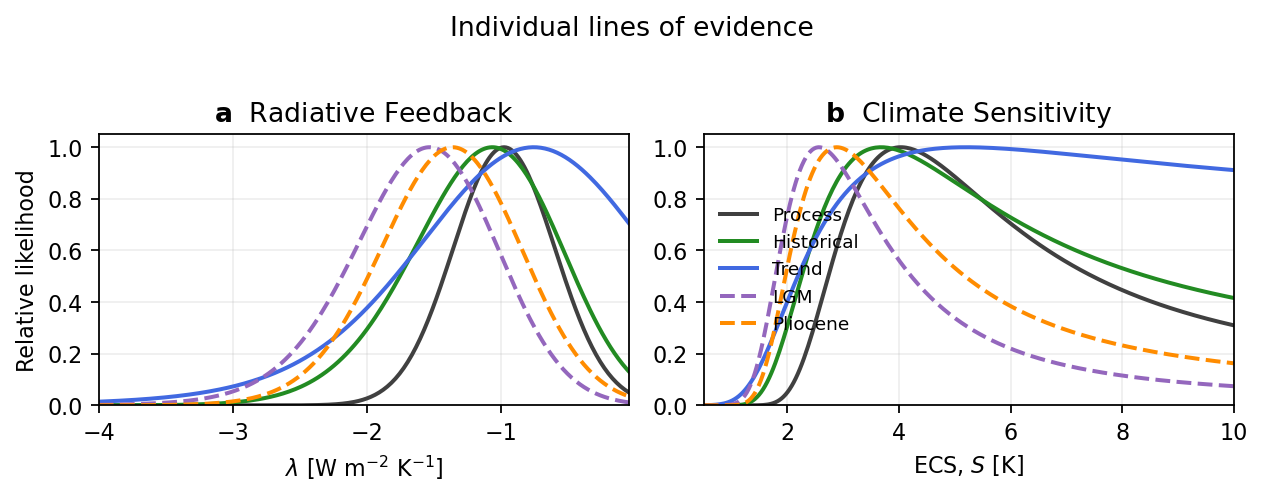

(<Figure size 1280x480 with 2 Axes>,
 array([<Axes: title={'center': '$\\mathbf{a}$  Radiative Feedback'}, xlabel='$\\lambda$ [W m$^{-2}$ K$^{-1}$]', ylabel='Relative likelihood'>,
        <Axes: title={'center': '$\\mathbf{b}$  Climate Sensitivity'}, xlabel='ECS, $S$ [K]'>],
       dtype=object))

In [49]:
likelihood_results = {}
likelihood_results["baseline"] = calculate_likelihoods(
    "baseline",
    process_correlation=bool(BASELINE_SWITCHES["use_lambda_F2x_correlation"]),
)

plot_likelihoods(
    likelihood_results["baseline"],
    evidence=INDIVIDUAL_EVIDENCE,
    title="Individual lines of evidence",
)

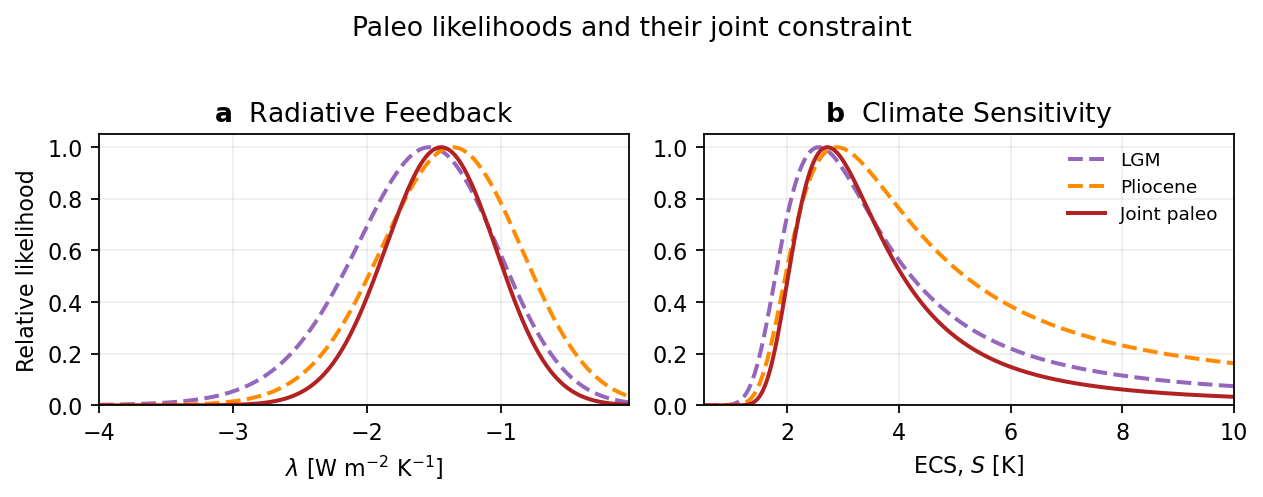

(<Figure size 1280x480 with 2 Axes>,
 array([<Axes: title={'center': '$\\mathbf{a}$  Radiative Feedback'}, xlabel='$\\lambda$ [W m$^{-2}$ K$^{-1}$]', ylabel='Relative likelihood'>,
        <Axes: title={'center': '$\\mathbf{b}$  Climate Sensitivity'}, xlabel='ECS, $S$ [K]'>],
       dtype=object))

In [51]:
# Joint paleo uses shared forcing/state-dependence draws and the assessed
# LGM-Pliocene pattern-effect correlation. It is not L_LGM * L_Pliocene.
plot_likelihoods(
    likelihood_results["baseline"],
    evidence=PALEO_EVIDENCE,
    title="Paleo likelihoods and their joint constraint",
)

### Sensitivity versions

Add named calculations to `likelihood_results`, changing only the parameters of interest. Because every version uses the same default seed, unchanged nuisance draws use common random numbers and differences between curves remain visually clean.

In [ ]:
# Example: show how the optional lambda/F2x Process correlation changes
# the Process likelihood in S space. Its lambda marginal is unchanged.
# likelihood_results["Process rho=-0.5"] = calculate_likelihoods(
#     "Process rho=-0.5", process_correlation=True
# )
# plot_likelihood_versions(
#     {
#         "independent": likelihood_results["baseline"],
#         r"$\rho=-0.5$": likelihood_results["Process rho=-0.5"],
#     },
#     evidence="Process",
# )

# Example: alternative LGM state-dependence multiplier uncertainty.
# likelihood_results["LGM multiplier sigma=0.08"] = calculate_likelihoods(
#     "LGM multiplier sigma=0.08",
#     input_updates={"sig_f_CO2_LGM": 0.08},
# )
# plot_likelihood_versions(
#     {
#         "baseline": likelihood_results["baseline"],
#         r"$\sigma(f_{CO2,LGM})=0.08$": likelihood_results["LGM multiplier sigma=0.08"],
#     },
#     evidence="LGM",
# )

# For a higher-resolution final figure:
# final_settings = {"grid_points": 600, "mc_draws": 150_000}
# likelihood_results["final"] = calculate_likelihoods(
#     "final", settings_updates=final_settings
# )